# Import Liabraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load Dataset

In [15]:
df=pd.read_csv('student-scores.csv')
print(df.head(10))


   id first_name  last_name                                  email  gender  \
0   1       Paul      Casey         paul.casey.1@gslingacademy.com    male   
1   2   Danielle   Sandoval  danielle.sandoval.2@gslingacademy.com  female   
2   3       Tina    Andrews       tina.andrews.3@gslingacademy.com  female   
3   4       Tara      Clark         tara.clark.4@gslingacademy.com  female   
4   5    Anthony     Campos     anthony.campos.5@gslingacademy.com    male   
5   6      Kelly       Wade         kelly.wade.6@gslingacademy.com  female   
6   7    Anthony      Smith      anthony.smith.7@gslingacademy.com    male   
7   8     George      Short       george.short.8@gslingacademy.com    male   
8   9    Stanley  Gutierrez  stanley.gutierrez.9@gslingacademy.com    male   
9  10     Audrey    Simpson    audrey.simpson.10@gslingacademy.com  female   

   part_time_job  absence_days  extracurricular_activities  \
0          False             3                       False   
1          False 

# columns

In [14]:
print(df.columns)

Index(['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job',
       'absence_days', 'extracurricular_activities', 'weekly_self_study_hours',
       'career_aspiration', 'math_score', 'history_score', 'physics_score',
       'chemistry_score', 'biology_score', 'english_score', 'geography_score'],
      dtype='str')


# Data Inspection

In [7]:
print(df.shape)
print(df.size)
print(df.isna().sum())




(2000, 17)
34000
id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64


In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          2000 non-null   int64
 1   first_name                  2000 non-null   str  
 2   last_name                   2000 non-null   str  
 3   email                       2000 non-null   str  
 4   gender                      2000 non-null   str  
 5   part_time_job               2000 non-null   bool 
 6   absence_days                2000 non-null   int64
 7   extracurricular_activities  2000 non-null   bool 
 8   weekly_self_study_hours     2000 non-null   int64
 9   career_aspiration           2000 non-null   str  
 10  math_score                  2000 non-null   int64
 11  history_score               2000 non-null   int64
 12  physics_score               2000 non-null   int64
 13  chemistry_score             2000 non-null   int64
 14  biology_score      

In [9]:
print(df.describe())

                id  absence_days  weekly_self_study_hours   math_score  \
count  2000.000000   2000.000000              2000.000000  2000.000000   
mean   1000.500000      3.665500                17.755500    83.452000   
std     577.494589      2.629271                12.129604    13.224906   
min       1.000000      0.000000                 0.000000    40.000000   
25%     500.750000      2.000000                 5.000000    77.000000   
50%    1000.500000      3.000000                18.000000    87.000000   
75%    1500.250000      5.000000                28.000000    93.000000   
max    2000.000000     10.000000                50.000000   100.000000   

       history_score  physics_score  chemistry_score  biology_score  \
count    2000.000000    2000.000000      2000.000000     2000.00000   
mean       80.332000      81.336500        79.995000       79.58150   
std        12.736046      12.539453        12.777895       13.72219   
min        50.000000      50.000000        50.000

# Data Cleaning

In [10]:
print(df.duplicated().sum())

0


# Total & Average Marks

In [19]:
subjects=['math_score','history_score','physics_score','chemistry_score','biology_score','english_score','geography_score']
df["total"]=df[subjects].sum(axis=1)
df["average"]=df["total"]/len(subjects)
print(df[["total","average"]])

      total    average
0       574  82.000000
1       640  91.428571
2       605  86.428571
3       551  78.714286
4       521  74.428571
...     ...        ...
1995    558  79.714286
1996    534  76.285714
1997    578  82.571429
1998    566  80.857143
1999    617  88.142857

[2000 rows x 2 columns]


# Ranking

In [ ]:
df["rank"] = df["total"].rank(ascending=False,method='dense')
df.sort_values(by="rank",inplace=True)
print(df["rank"])

796     1.0
779     2.0
1573    NaN
1419    NaN
551     NaN
       ... 
819     NaN
527     NaN
906     NaN
1661    NaN
1965    NaN
Name: rank, Length: 2000, dtype: float64


# Subjectwise Analysis

In [24]:
subjects_analysis = pd.DataFrame({
    "Mean":df[subjects].mean(),
    "Median":df[subjects].median(),
    "max":df[subjects].max(),
    "min":df[subjects].min()
})
print(subjects_analysis)

                    Mean  Median  max  min
math_score       83.4520    87.0  100   40
history_score    80.3320    82.0  100   50
physics_score    81.3365    83.0  100   50
chemistry_score  79.9950    81.0  100   50
biology_score    79.5815    81.0  100   30
english_score    81.2775    83.0   99   50
geography_score  80.8880    81.0  100   60


# Percentile Of Each

In [25]:
df["percentage"]=(df["total"]/(len(subjects)*100))*100
print(df.sort_values(by="percentage", ascending=False))

        id first_name  last_name                                    email  \
796    797       Lisa   Mitchell      lisa.mitchell.797@gslingacademy.com   
779    780       Todd     Howard        todd.howard.780@gslingacademy.com   
1573  1574      Paula  Hernandez   paula.hernandez.1574@gslingacademy.com   
1419  1420       Mary     Arnold       mary.arnold.1420@gslingacademy.com   
551    552       Paul    Shaffer       paul.shaffer.552@gslingacademy.com   
...    ...        ...        ...                                      ...   
819    820     Steven    Alvarez     steven.alvarez.820@gslingacademy.com   
527    528    Deborah      Rojas      deborah.rojas.528@gslingacademy.com   
906    907     Alicia    Beltran     alicia.beltran.907@gslingacademy.com   
1661  1662     Thomas      Scott      thomas.scott.1662@gslingacademy.com   
1965  1966   Jennifer    Leblanc  jennifer.leblanc.1966@gslingacademy.com   

      gender  part_time_job  absence_days  extracurricular_activities  \
79

# Grade Assignning

In [26]:
def grade(percentage):
    if percentage >= 90:
        return 'A'
    elif percentage >= 80:
        return 'B'
    elif percentage >= 70:
        return 'C'
    elif percentage >= 60:
        return 'D'
    elif percentage >= 50:
        return 'F'
    else:
        return 'FAIL'
    
print(df["percentage"].apply(grade))

796     A
779     A
1573    A
1419    A
551     A
       ..
819     D
527     D
906     D
1661    F
1965    F
Name: percentage, Length: 2000, dtype: str


# Top & Weak Student Analysis


In [29]:
#top 3 students based on percentile
top_student = df.sort_values(by='percentage',ascending=False)[['first_name','last_name','percentage']].head(3)
print(top_student)

     first_name  last_name  percentage
796        Lisa   Mitchell   96.142857
779        Todd     Howard   95.857143
1573      Paula  Hernandez   95.857143


In [31]:
#Weak Students
weak_students = df[df["percentage"]<50][['first_name','percentage']]
print(weak_students)

Empty DataFrame
Columns: [first_name, percentage]
Index: []


In [32]:
#Topper rank 1 student details
topper = df.loc[df["percentage"].idxmax()]
print(topper)

id                                                            797
first_name                                                   Lisa
last_name                                                Mitchell
email                         lisa.mitchell.797@gslingacademy.com
gender                                                     female
part_time_job                                               False
absence_days                                                    3
extracurricular_activities                                   True
weekly_self_study_hours                                        35
career_aspiration                                          Banker
math_score                                                     87
history_score                                                  99
physics_score                                                  99
chemistry_score                                               100
biology_score                                                  98
english_sc

In [33]:
#weakest student details
weakest_student =df.loc[df["percentage"].idxmin()]
print(weakest_student)

id                                                           1662
first_name                                                 Thomas
last_name                                                   Scott
email                         thomas.scott.1662@gslingacademy.com
gender                                                       male
part_time_job                                                True
absence_days                                                    6
extracurricular_activities                                  False
weekly_self_study_hours                                         5
career_aspiration                                  Business Owner
math_score                                                     41
history_score                                                  53
physics_score                                                  64
chemistry_score                                                62
biology_score                                                  79
english_sc

In [34]:
#performance visulaization
df["performance"]=pd.cut(df["percentage"],
                         bins=[0,50,60,70,80,90,100],
                         labels=['Fail','Need Improvement','Average','Good','Very Good','Excellent'])
print(df["performance"])

796            Excellent
779            Excellent
1573           Excellent
1419           Excellent
551            Excellent
              ...       
819              Average
527              Average
906              Average
1661    Need Improvement
1965    Need Improvement
Name: performance, Length: 2000, dtype: category
Categories (6, str): ['Fail' < 'Need Improvement' < 'Average' < 'Good' < 'Very Good' < 'Excellent']


# Visual Analysis


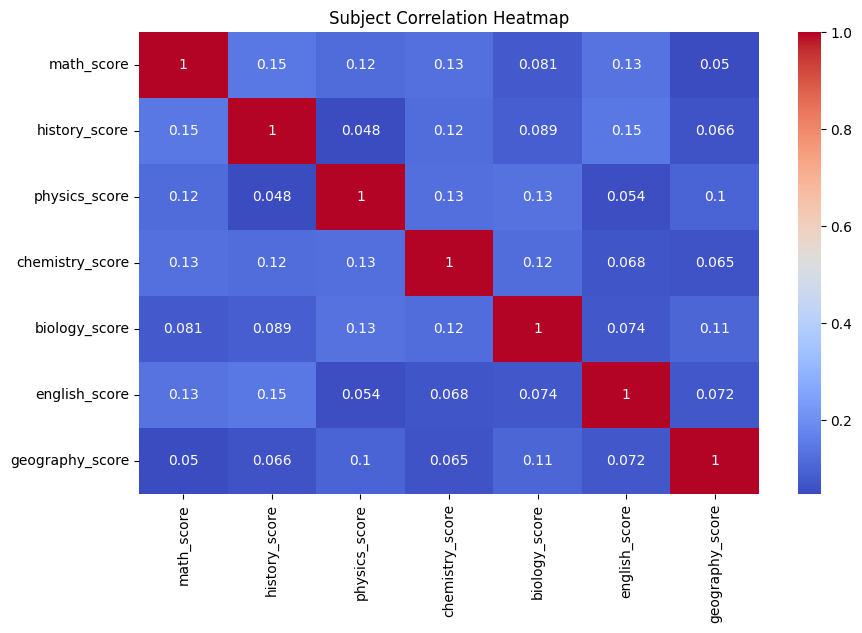

In [37]:
import seaborn as sns
df["Total"]=df[['math_score','history_score','physics_score','chemistry_score','biology_score','english_score','geography_score']].sum(axis=1)
plt.figure(figsize=(10,6))
sns.heatmap(df[['math_score','history_score','physics_score','chemistry_score','biology_score','english_score','geography_score']].corr(),annot=True,cmap="coolwarm")
plt.title("Subject Correlation Heatmap")
plt.show()


# Save to CSV


In [38]:
df.to_csv("student-scores.csv",index=False)